In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

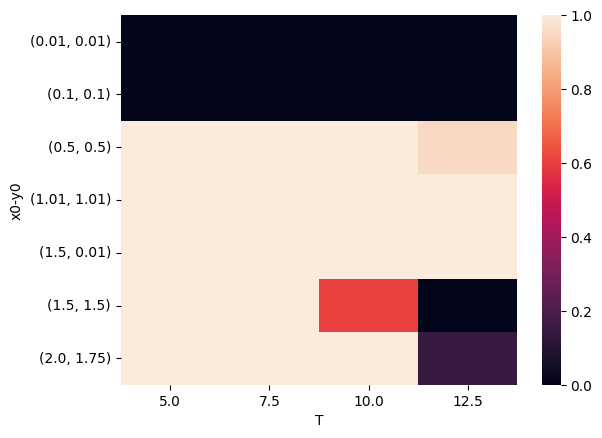

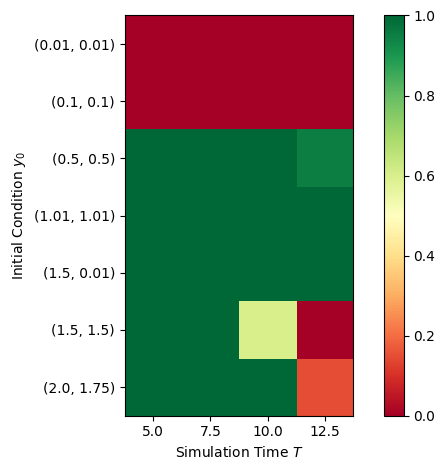

In [4]:
results1 = pd.read_csv("results_no_reg.csv")
results2 = pd.read_csv("results_no_reg_T12_5.csv")

results = pd.concat([results1, results2])

table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["x0-y0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $y_0$')


plt.tight_layout()
plt.show()

/tmp/ipykernel_16602/2476541628.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
/tmp/ipykernel_16602/2476541628.py:

<Axes: xlabel='x0', ylabel='y0'>

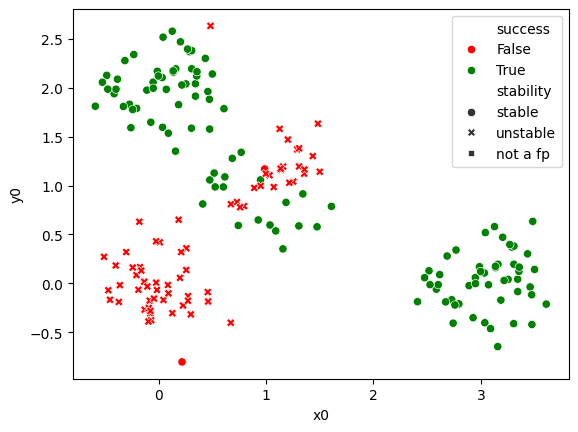

In [6]:
table_no_reg = pd.read_csv("convergence_points.csv")
table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
table_no_reg["x0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_no_reg["y0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_no_reg["xT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[0])
table_no_reg["yT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
sns.scatterplot(data=table_no_reg, x="x0", y="y0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])

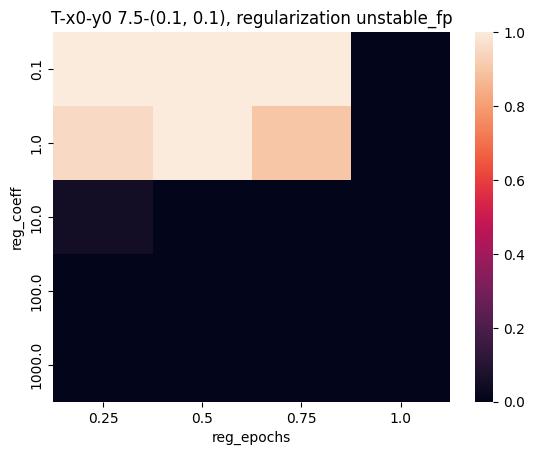

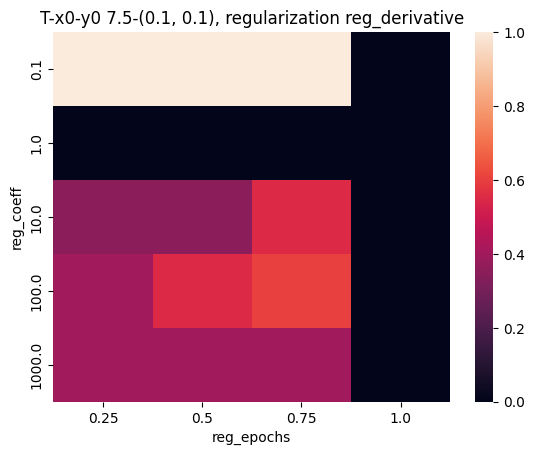

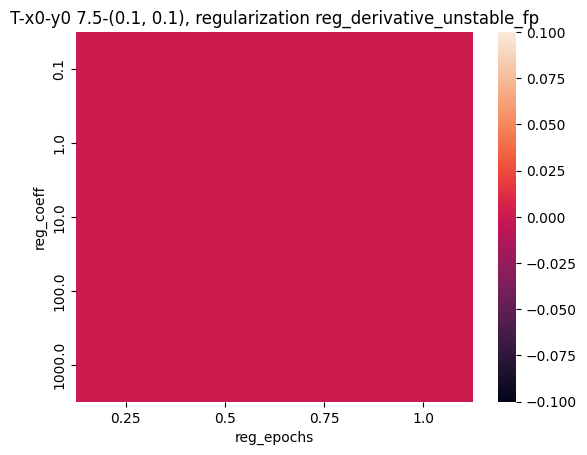

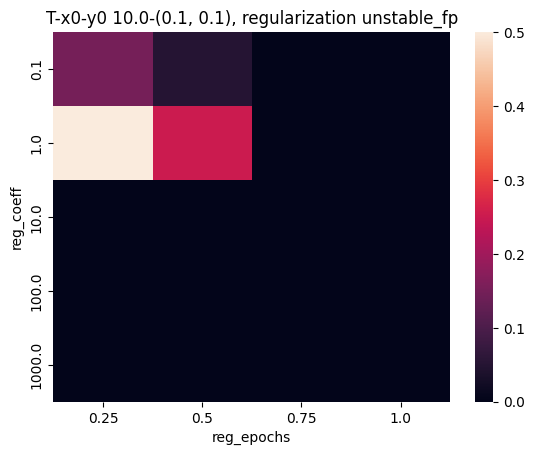

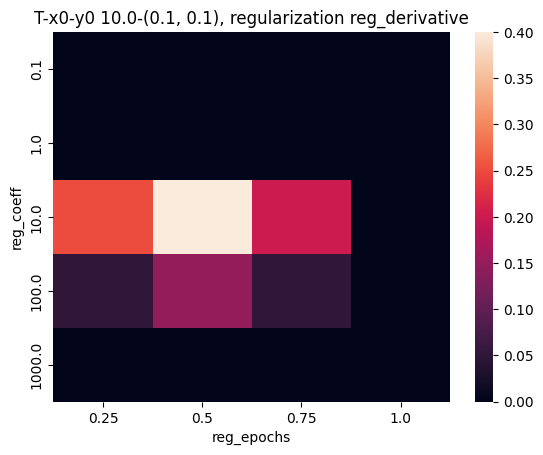

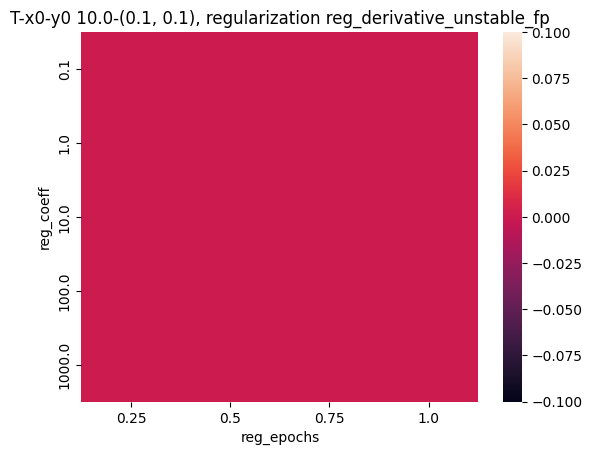

In [6]:
results = pd.read_csv("results_linear_decay.csv")

results["T-x0-y0"] = results["T"].astype(str) + "-" + results["x0-y0"].astype(str) 

for settings in results["T-x0-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table)
        plt.title(f"T-x0-y0 {settings}, regularization {regularization}")
        plt.show()